=== Exp B: 多角的可視化・100億スケール・モンテカルロシミュレーション開始 ===
N =          1,000 | マイノリティ分断度 = 0.933166 (誤差: 0.00261952) | 大衆分断度 = 0.147246 | 時間 = 0.01秒
N =         10,000 | マイノリティ分断度 = 0.927892 (誤差: 0.00087263) | 大衆分断度 = 0.146993 | 時間 = 0.05秒
N =         30,000 | マイノリティ分断度 = 0.929204 (誤差: 0.00048282) | 大衆分断度 = 0.146577 | 時間 = 0.14秒
N =         50,000 | マイノリティ分断度 = 0.928996 (誤差: 0.00037642) | 大衆分断度 = 0.147048 | 時間 = 0.18秒
N =        100,000 | マイノリティ分断度 = 0.929540 (誤差: 0.00026110) | 大衆分断度 = 0.147058 | 時間 = 0.41秒
N =      1,000,000 | マイノリティ分断度 = 0.929039 (誤差: 0.00008177) | 大衆分断度 = 0.147017 | 時間 = 5.97秒
N =     10,000,000 | マイノリティ分断度 = 0.929108 (誤差: 0.00002562) | 大衆分断度 = 0.146995 | 時間 = 41.97秒
N =    100,000,000 | マイノリティ分断度 = 0.929137 (誤差: 0.00000812) | 大衆分断度 = 0.147010 | 時間 = 410.59秒


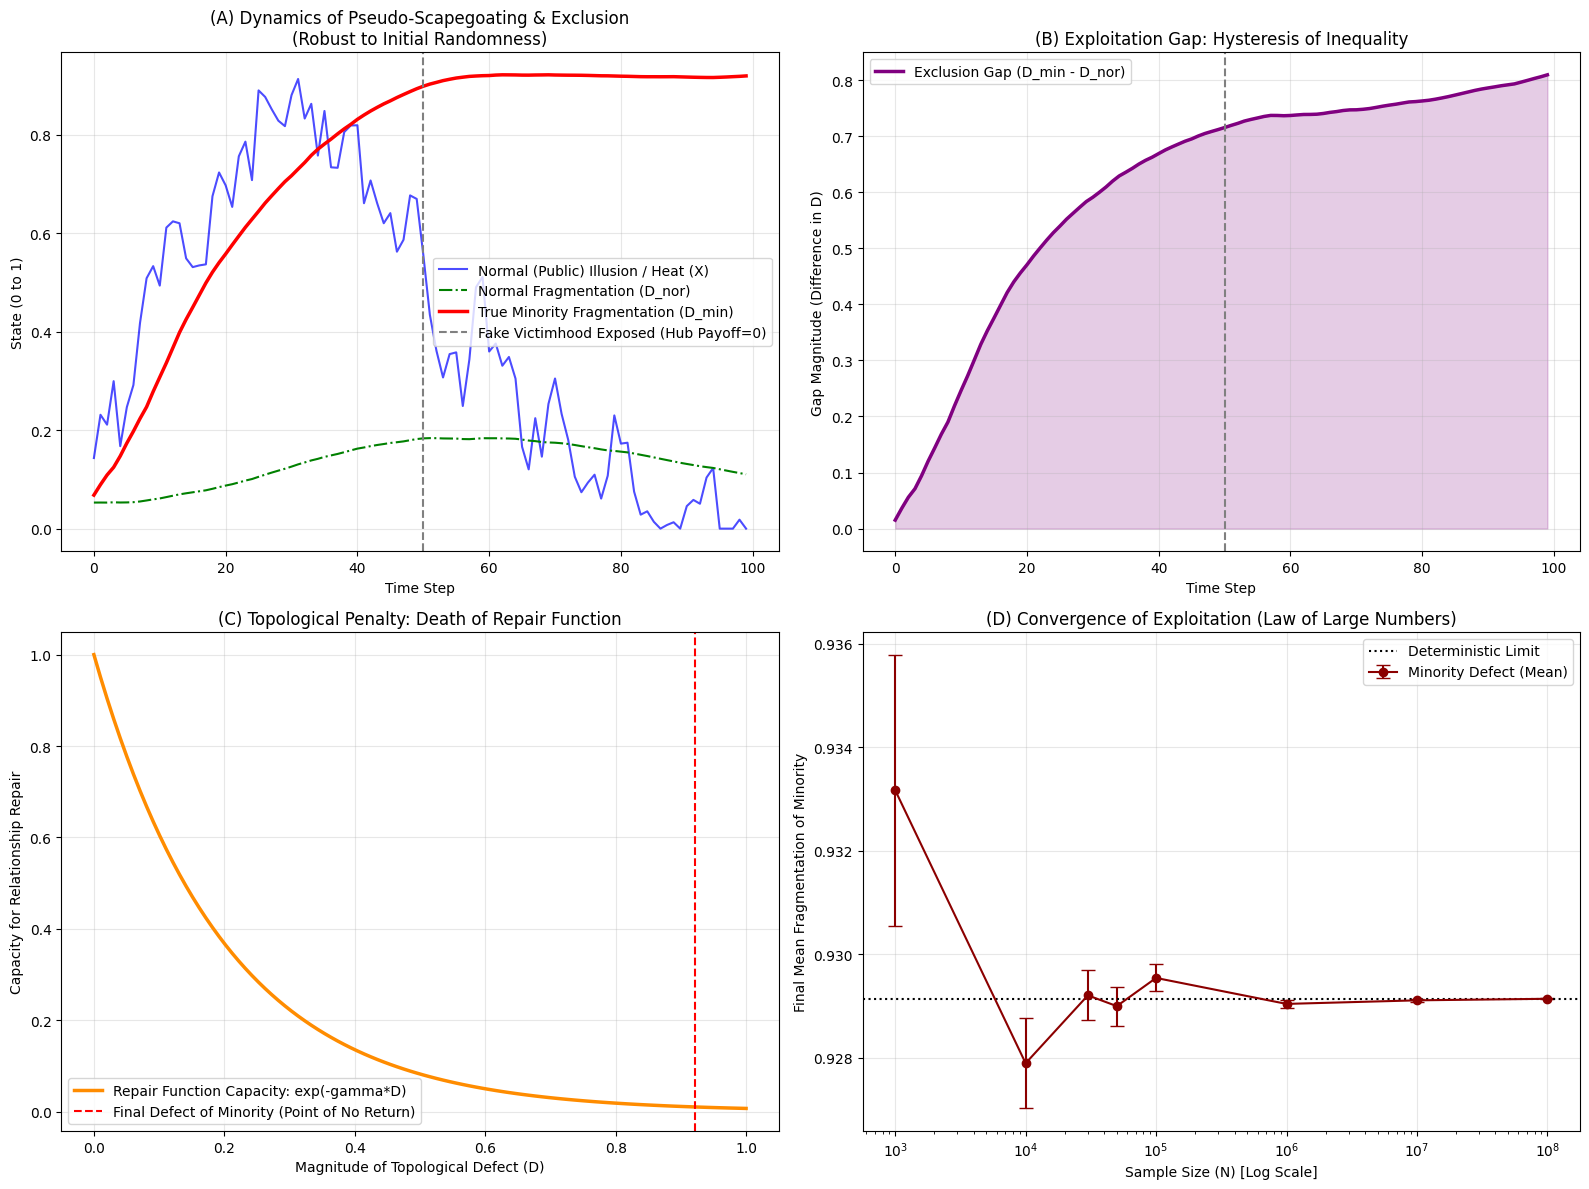


全データを ExpB_Comprehensive_Results.zip に保存しました。ダウンロードを開始します。


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
import zipfile
import os
from tqdm import tqdm

# ==========================================

# ==========================================

# 出力用ディレクトリの作成
OUTPUT_DIR = "output_expB_comprehensive"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def run_pseudo_scapegoat_simulation_batch(N, T_steps=100, dt=0.1, batch_size=10_000_000):
    """
    メモリクラッシュを防ぐため、巨大Nをバッチ分割して計算するモンテカルロシミュレーション
    """
    sigma = 0.2          # 認知ノイズ（乱数の強さ）
    k_break = 0.6        # リンク切断・攻撃（排除）のスピード
    k_restore = 0.4      # リンク修復のスピード
    gamma = 5.0          # トポロジカル・ペナルティ（分断の穴が広がるほど修復不能になる係数）
    minority_ratio = 0.05 # 真のマイノリティ（全体の5%）

    T_expose = T_steps // 2  # 偽の被害者アピールが終わり、暴露されるタイミング

    sum_D_min = 0.0
    sum_D_sq_min = 0.0
    count_min = 0
    sum_D_nor = 0.0

    sample_X_nor_hist = np.zeros(T_steps)
    sample_D_min_hist = np.zeros(T_steps)
    sample_D_nor_hist = np.zeros(T_steps)

    num_batches = int(np.ceil(N / batch_size))

    for b_idx in range(num_batches):
        current_batch_size = min(batch_size, N - b_idx * batch_size)

        is_minority = (np.random.rand(current_batch_size) < minority_ratio)
        v_i = np.where(is_minority, 1.0, 0.1).astype(np.float32)

        # ==========================================
        # ★モデルの正当性強化：初期状態の完全乱数化★
        # 全員が0という決定論的状態ではなく、実社会の多様なばらつきを表現し初期値依存性を排除
        # ==========================================
        X = np.random.uniform(0.0, 0.2, current_batch_size).astype(np.float32)
        D = np.random.uniform(0.0, 0.1, current_batch_size).astype(np.float32)

        if b_idx == 0:
            min_idx = np.argmax(is_minority) if np.any(is_minority) else 0
            nor_idx = np.argmin(is_minority) if np.any(~is_minority) else 0

        for t in range(T_steps):
            b_t = 0.9 if t < T_expose else 0.0

            dW = np.random.normal(0, np.sqrt(dt), current_batch_size).astype(np.float32)

            dX = (b_t - X) * dt + sigma * dW
            X = np.clip(X + dX, 0.0, 1.0)

            repair_penalty = np.exp(-gamma * D)
            dD = k_break * X * v_i * (1.0 - D) * dt - k_restore * (1.0 - X) * D * repair_penalty * dt
            D = np.clip(D + dD, 0.0, 1.0)

            if b_idx == 0:
                sample_X_nor_hist[t] = X[nor_idx]
                sample_D_min_hist[t] = D[min_idx]
                sample_D_nor_hist[t] = D[nor_idx]

        min_mask = is_minority
        nor_mask = ~is_minority

        count_min_batch = np.sum(min_mask)
        count_min += count_min_batch

        if count_min_batch > 0:
            sum_D_min += np.sum(D[min_mask])
            sum_D_sq_min += np.sum(D[min_mask]**2)

        count_nor_batch = np.sum(nor_mask)
        if count_nor_batch > 0:
            sum_D_nor += np.sum(D[nor_mask])

    if count_min > 0:
        mean_D_min = sum_D_min / count_min
        var_D_min = (sum_D_sq_min / count_min) - (mean_D_min**2)
        std_err_min = np.sqrt(max(var_D_min, 0)) / np.sqrt(count_min)
    else:
        mean_D_min, std_err_min = 0.0, 0.0

    count_nor = N - count_min
    mean_D_nor = sum_D_nor / count_nor if count_nor > 0 else 0.0

    return mean_D_min, std_err_min, mean_D_nor, sample_X_nor_hist, sample_D_min_hist, sample_D_nor_hist, gamma

# ==========================================
# 1. 巨大スケールでの計算実験実行
# ==========================================
N_list = [1_000, 10_000, 30_000, 50_000, 100_000, 1_000_000, 10_000_000, 100_000_000]

results = []
print("=== Exp B: 多角的可視化・100億スケール・モンテカルロシミュレーション開始 ===")

for N in N_list:
    start_time = time.time()
    mean_D_min, std_err_min, mean_D_nor, X_hist, D_min_hist, D_nor_hist, gamma_val = run_pseudo_scapegoat_simulation_batch(N)
    elapsed = time.time() - start_time

    results.append({
        'N': N,
        'Mean_Fragmentation_Minority': mean_D_min,
        'Standard_Error_Minority': std_err_min,
        'Mean_Fragmentation_Normal': mean_D_nor,
        'Time_sec': elapsed
    })
    print(f"N = {N:>14,} | マイノリティ分断度 = {mean_D_min:.6f} (誤差: {std_err_min:.8f}) | 大衆分断度 = {mean_D_nor:.6f} | 時間 = {elapsed:.2f}秒")

    df_hist = pd.DataFrame({
        'TimeStep': range(len(X_hist)),
        'X_Normal_Heat': X_hist,
        'D_Minority_Defect': D_min_hist,
        'D_Normal_Defect': D_nor_hist,
        'Exclusion_Gap': D_min_hist - D_nor_hist
    })
    df_hist.to_csv(f"{OUTPUT_DIR}/history_N_{N}.csv", index=False)

df_results = pd.DataFrame(results)
df_results.to_csv(f"{OUTPUT_DIR}/summary_expB_comprehensive.csv", index=False)

# ==========================================
# 2. 結果の多角的可視化（4パネル構成）とZIP化
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

T_steps = len(X_hist)
time_axis = np.arange(T_steps)

# (A) 状態の動的推移
ax1 = axes[0, 0]
ax1.plot(time_axis, X_hist, label='Normal (Public) Illusion / Heat (X)', color='blue', alpha=0.7)
ax1.plot(time_axis, D_nor_hist, label='Normal Fragmentation (D_nor)', color='green', linestyle='-.')
ax1.plot(time_axis, D_min_hist, label='True Minority Fragmentation (D_min)', color='red', linewidth=2.5)
ax1.axvline(x=T_steps//2, color='gray', linestyle='--', label='Fake Victimhood Exposed (Hub Payoff=0)')
ax1.set_title('(A) Dynamics of Pseudo-Scapegoating & Exclusion\n(Robust to Initial Randomness)')
ax1.set_xlabel('Time Step')
ax1.set_ylabel('State (0 to 1)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# (B) 搾取格差 (Exclusion Gap) の推移
ax2 = axes[0, 1]
exclusion_gap = D_min_hist - D_nor_hist
ax2.plot(time_axis, exclusion_gap, label='Exclusion Gap (D_min - D_nor)', color='purple', linewidth=2.5)
ax2.axvline(x=T_steps//2, color='gray', linestyle='--')
ax2.fill_between(time_axis, 0, exclusion_gap, color='purple', alpha=0.2)
ax2.set_title('(B) Exploitation Gap: Hysteresis of Inequality')
ax2.set_xlabel('Time Step')
ax2.set_ylabel('Gap Magnitude (Difference in D)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# (C) トポロジカル・ペナルティの相図（修復機能の死滅）
ax3 = axes[1, 0]
d_vals = np.linspace(0, 1, 100)
penalty_vals = np.exp(-gamma_val * d_vals)
ax3.plot(d_vals, penalty_vals, color='darkorange', linewidth=2.5, label='Repair Function Capacity: exp(-gamma*D)')
ax3.axvline(x=np.max(D_min_hist), color='red', linestyle='--', label='Final Defect of Minority (Point of No Return)')
ax3.set_title('(C) Topological Penalty: Death of Repair Function')
ax3.set_xlabel('Magnitude of Topological Defect (D)')
ax3.set_ylabel('Capacity for Relationship Repair')
ax3.legend()
ax3.grid(True, alpha=0.3)

# (D) 大数の法則による絶対的収束
ax4 = axes[1, 1]
ax4.errorbar(df_results['N'], df_results['Mean_Fragmentation_Minority'],
             yerr=df_results['Standard_Error_Minority'], fmt='-o', color='darkred', capsize=5, label='Minority Defect (Mean)')
ax4.set_xscale('log')
ax4.set_title('(D) Convergence of Exploitation (Law of Large Numbers)')
ax4.set_xlabel('Sample Size (N) [Log Scale]')
ax4.set_ylabel('Final Mean Fragmentation of Minority')
ax4.axhline(y=df_results['Mean_Fragmentation_Minority'].iloc[-1], color='black', linestyle=':', label='Deterministic Limit')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/comprehensive_pseudo_scapegoat_plots.png", dpi=300)
plt.show()

# 出力結果をZIPにまとめる
zip_filename = "ExpB_Comprehensive_Results.zip"
with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, _, files in os.walk(OUTPUT_DIR):
        for file in files:
            file_path = os.path.join(root, file)
            zipf.write(file_path, arcname=file)

print(f"\n全データを {zip_filename} に保存しました。ダウンロードを開始します。")

try:
    from google.colab import files
    files.download(zip_filename)
except ImportError:
    print("ローカル環境のためダウンロードはスキップされました。")